In [1]:
!pip install rasterio numpy


In [2]:
import rasterio 
import numpy as np
import os 
from rasterio.windows import Window

In [3]:
Files = {
    "SVF" : "Sample3svf.tif",
    "Openness" : "sample3openess_pos.tif",
    "Slope":"sample3slope.tif"
}
# Channel order : R , G , B
Channel_orders = ["SVF","Openness" , "Slope"]  # R = SVF , G = Openness , B = Slope

# Fixed stretch value using cutoff percentile(2-98th Percentile)
cutoff = {
    "SVF" : (0.7210 , 0.9931),
    "Openness": (77.4913 , 91.2449),
    "Slope" : (0.7164 ,36.1389)
}

os.makedirs("/Users/rajkamal0raon/Desktop/dataset1",exist_ok = True)
Output_RGB_path = "/Users/rajkamal0raon/Desktop/dataset1/full_site_RGB1.tif"





In [4]:
# MIN_MAX Normalisation
def contrast_stretch(arr , low_pnct,high_pnct):
    arr = arr.astype("float32")
    stretched = (arr-low_pnct)/(high_pnct-low_pnct)*255.0  # min-max normalization formula
    stretched = np.clip(stretched,0,255)
    return stretched.astype("uint8")

In [5]:
# RGB COMPOSITION
def rgb_composite(input_dir , files, Channel_orders, cutoff,Output_RGB_path):
    band_arrs = []
    ref_profile = None
    ref_shape = None

    for name in Channel_orders:
        path = os.path.join(input_dir , files[name])
        with rasterio.open(path) as ds:
            if ref_profile is None:
                ref_profile = ds.profile.copy() # save metadata such as CRS, transform,size
                ref_shape = (ds.height , ds.width)
            else:
                # all bands must share the same grids
                if (ds.height,ds.width)!= ref_shape:
                    raise ValueError(
                        f" '{name}' raster shape {(ds.height,ds.width)}"
                        f" does not match the reference shape {ref_shape}"
                        " Resample inputs to common grid first"
                    )
            # Read and process each band 
            data = ds.read(1 , masked = True)
            filled = data.filled(0)  # replace nodata with 0 to preserve grid shape
            
        low_pnct , high_pnct = cutoff[name]
        band_arrs.append(contrast_stretch(filled,low_pnct , high_pnct))
        
    # Combine SVF, Openness and Slope into 3-band RGB composite (shape: 3,H,W)
    rgb = np.stack(band_arrs , axis = 0) 


    out_profile = ref_profile.copy()
    out_profile.update(
        dtype = "uint8", # save as 0-255 values
        count = 3,       # 3 bands (R,G,B) instead of original 1 band
        photometric = "RGB", # tells GIS software to display as colour
        compress = "deflate", # compress to save disk space
        nodata = None     # no nodata value (already filled with 0)
    )

    # create out folder if it doesnt exist
    os.makedirs(os.path.dirname(Output_RGB_path),exist_ok = True)

    # RGB composite to GeoTIFF file
    with rasterio.open(Output_RGB_path,"w",**out_profile) as rgb_file:
        rgb_file.write(rgb)

        # assign colour interpretation so GIS software display band correctly
        rgb_file.colorinterp= [
            rasterio.enums.ColorInterp.red,
            rasterio.enums.ColorInterp.green,
            rasterio.enums.ColorInterp.blue,
        ]

    print(f" RGB composite : {Output_RGB_path} (shape: {rgb.shape})")
    return Output_RGB_path
        
            
               
                  
       

In [6]:
Input_Dir = "."
rgb_path = rgb_composite(Input_Dir, Files, Channel_orders, cutoff,Output_RGB_path) 

 RGB composite : /Users/rajkamal0raon/Desktop/dataset1/full_site_RGB1.tif (shape: (3, 20000, 20000))


In [7]:
print(os.path.exists(Output_RGB_path))
print(os.path.getsize(Output_RGB_path)/1e6,"MB")

True
1064.342698 MB


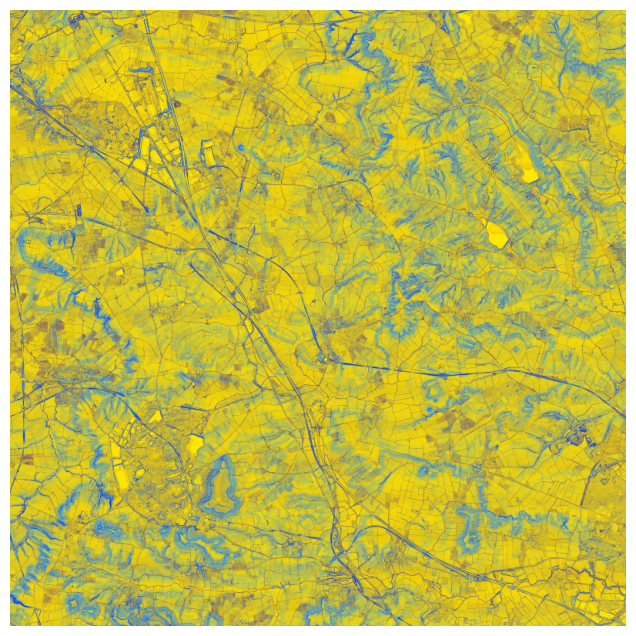

In [8]:
from rasterio.enums import Resampling
import matplotlib.pyplot as plt

# read RGB composite at reduced resolution
with rasterio.open(Output_RGB_path) as ds:
    image = ds.read(out_shape = (3,800,800) , resampling = Resampling.average)
# display RGB composite
plt.figure(figsize = (8,8))
plt.imshow(image.transpose(1,2,0))  # rearrange from (3,H,W) to (H,W,3) for matplotlib
plt.axis("off")
plt.show()


In [9]:
# TILING OF DATA

In [10]:
def tile_data(input_path , tile_dir,tile_size = 640 , overlap = 128):
    # split data into tile size * tile size GeoTIFF tiles

    os.makedirs(tile_dir , exist_ok = True)
    step = tile_size-overlap
    tiles_written = 0
    with rasterio.open(input_path) as ds:
        width , height = ds.width, ds.height

        for top in range(0,height,step): # move down
            for left in range(0,width,step): # move right
                window_width = min(tile_size,width -left)
                window_height = min(tile_size,height-top)
                if window_width <=0 or window_height <=0:
                    continue
                window = Window(left,top,window_width,window_height)  # create the window
                
                transform = ds.window_transform(window)  # get geographic position
                tile_array = ds.read(window = window) # read the tile data 
                tile_profile = ds.profile.copy()
                tile_profile.update(
                    height = window_height,
                    width = window_width,
                    transform = transform,
                )

                # save each tile as a separate GeoTIFF
                tile_name = f"tile_{top}_{left}.tif"
                tile_path = os.path.join(tile_dir , tile_name)
                with rasterio.open(tile_path , "w",**tile_profile) as f:
                    f.write(tile_array)
                tiles_written +=1

    print(f"{tiles_written} tiles written :{tile_dir}")
    return tiles_written
                
             
                
                 
                

In [11]:
Tile_dir = "/Users/rajkamal0raon/Desktop/dataset1/tiles"
tile_data(Output_RGB_path,Tile_dir , tile_size = 640 , overlap = 128)



1600 tiles written :/Users/rajkamal0raon/Desktop/dataset1/tiles


1600

In [19]:
# Sanity check to verify the tiles were created correctly

files = os.listdir(Tile_dir)
print("Total files :", len(files))
print("sample names:",files[:5])

# check all files for zero size
zero_files = 0
for f in files:
    size = os.path.getsize(os.path.join(Tile_dir,f))
    if size == 0:
        zero_files +=1
        print(f"WARNING : {f} is empty")
if zero_files == 0:
    print("All tiles have data")
else:
    print(f"{zero_files} empty files found")





Total files : 1600
sample names: ['tile_19456_9216.tif', 'tile_18944_11264.tif', 'tile_15872_15360.tif', 'tile_512_15872.tif', 'tile_9216_512.tif']
All tiles have data


In [20]:
#conversion into JPG for detection 
from PIL import Image

tif_dir = Tile_dir 
jpg_dir = "/Users/rajkamal0raon/Desktop/dataset1/tiles_jpg"
os.makedirs(jpg_dir , exist_ok = True)

converted = 0
for tile in os.listdir(tif_dir):
    if tile.endswith(".tif"):
        
        # read GeoTIFF
        with rasterio.open(os.path.join(tif_dir,tile))as ds:
            arr = ds.read()   # shape:(3,H,W)

        # convert to JPG
        img = np.transpose(arr,(1,2,0))  # rearrange to (H,W,3) for PIL
        out_name = tile.replace(".tif",".jpg")
        Image.fromarray(img, mode = "RGB").save(os.path.join(jpg_dir , out_name), quality = 95)
        converted +=1

print(f"{converted} tiles converted to JPG : {jpg_dir}")
            


1600 tiles converted to JPG : /Users/rajkamal0raon/Desktop/dataset1/tiles_jpg


In [22]:
print(os.path.abspath("tiles_jpg"))
print(os.path.abspath("tiles"))



/Users/rajkamal0raon/tiles_jpg
/Users/rajkamal0raon/tiles


In [25]:
with rasterio.open("full_site_RGB1.tif")as ds:
    print("Raster CRS :", ds.crs)
    print("Raster Bounds:",ds.bounds)


Raster CRS : EPSG:27700
Raster Bounds: BoundingBox(left=452000.0, bottom=258000.0, right=472000.0, top=278000.0)


In [1]:
import shutil
shutil.make_archive(
    "/Users/rajkamal0raon/Desktop/dataset1/tiles_jpg_final_zip",
    "zip",
    "/Users/rajkamal0raon/Desktop/dataset1/tiles_jpg"
)
print("Zipped!")

Zipped!
